In [1]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
%matplotlib inline

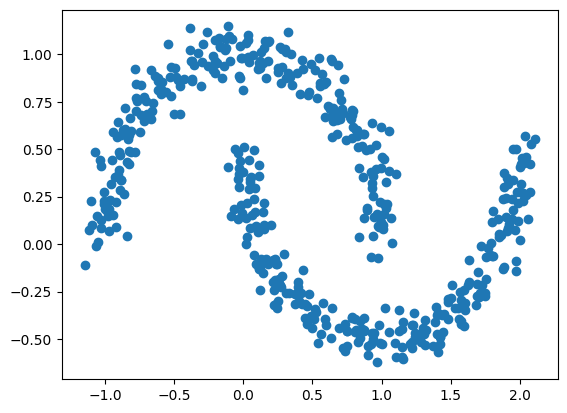

In [2]:
data = make_moons(500, noise=0.07, shuffle=True)
xs = [p[0] for p in data[0]]
ys = [p[1] for p in data[0]]
plt.scatter(xs, ys)

In [3]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(data[0], data[1], test_size=0.2, train_size=0.8)

In [4]:
from micrograd.day02_implementation.nn import MLP

In [5]:
nn = MLP(2, [4, 4, 1])

In [6]:
x_train

array([[ 1.94481380e+00,  2.36670012e-01],
       [ 7.47841965e-01, -4.57079816e-01],
       [ 1.28358158e+00, -4.75617149e-01],
       [ 1.22577577e+00, -4.27659019e-01],
       [ 1.94940321e+00,  1.77565342e-01],
       [-6.14904708e-01,  8.12924802e-01],
       [ 8.23271011e-01,  5.70417320e-01],
       [ 7.20195893e-01,  6.91809528e-01],
       [ 5.25364288e-01, -3.57835056e-01],
       [ 1.80010368e+00, -6.45234745e-02],
       [ 1.85045553e+00,  5.07315053e-02],
       [ 4.24603984e-01, -3.17796374e-01],
       [ 1.05230150e+00, -4.63197427e-01],
       [ 9.78862663e-01,  9.05267416e-02],
       [ 1.86557845e+00,  4.63608519e-02],
       [ 6.76946852e-02,  9.94567244e-01],
       [ 6.47234243e-01,  6.50489025e-01],
       [-9.13183413e-01,  5.61866088e-01],
       [ 7.94113000e-01,  6.19602181e-01],
       [ 7.58503558e-02,  2.36418415e-01],
       [ 1.41992896e+00, -4.90168334e-01],
       [ 1.10033738e-01,  9.21937800e-01],
       [ 1.76656149e+00, -1.80491251e-02],
       [ 2.

In [7]:
step_size = 0.1

losses = []

for i in range(250):
    # Forward pass on all training data
    preds = [nn(x) for x in x_train]

    # loss - MSE
    loss = sum((pred - y) ** 2 for pred, y in zip(preds, y_train)) / len(y_train)
    losses.append(loss.data)

    # Zero gradients before backward
    nn.zero_grad()

    # Single backward pass
    loss.backward()

    # Single update per epoch
    for p in nn.parameters():
        p.data -= step_size * p.grad

    if i % 50 == 0:
        print(f"Epoch {i} - Loss {loss}")

Epoch 0 - Loss Value(data=0.5283368428105844)
Epoch 50 - Loss Value(data=0.10535783114858555)
Epoch 100 - Loss Value(data=0.08326805553692021)
Epoch 150 - Loss Value(data=0.07581224593359216)
Epoch 200 - Loss Value(data=0.07283476217137824)


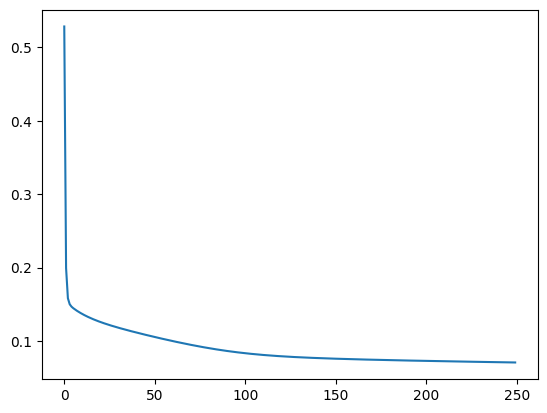

In [8]:
plt.plot(losses)